<a href="https://colab.research.google.com/github/harshraj-16/Handwritten-Digit-Classification-Perceptron-vs-ANN-vs-CNN-/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

df_train = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

# print(df)
# print(df.shape)
# df.columns

x_train = df_train.drop("label",axis=1).values
y_train = df_train['label'].values
x_test = df_test.drop("label",axis=1).values
y_test = df_test['label'].values

x_train = x_train.astype("float32")/255.0   #convert 0-255 range ---> 0.0 - 255.0 ---> then 0-1 range in 0.0 and 1.0 for better traing
x_test = x_test.astype("float32")/255.0     #convert 0-255 range ---> 0.0 - 255.0 ---> then 0-1 range in 0.0 and 1.0 for better traing

x_train_img = x_train.reshape(-1,28,28)  # conver 1D into 2D
x_test_img = x_test.reshape(-1,28,28)   # conver 1D into 2D

# print(x_train_img)

y_train_cat = to_categorical(y_train,10)  #Apply One-Hot encoding
y_test_cat = to_categorical(y_test,10)

print(y_test_cat)

perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation="softmax")
])

perceptron.compile(optimizer="sgd",loss="categorical_crossentropy",metrics=["accuracy"])

history_percp = perceptron.fit(x_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(x_test_img, y_test_cat), verbose=1)
acc_percp = perceptron.evaluate(x_test_img,y_test_cat,verbose=0)[1]
print(acc_percp)

print("-----------------ANN--------------------------")
# ANN

ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
])

ann.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

history_ann = ann.fit(x_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(x_test_img,y_test_cat),verbose=1)
acc_ann = ann.evaluate(x_test_img,y_test_cat,verbose=0)[1]
print(acc_ann)

print("------------------CNN----------------------")

x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

cnn = Sequential([
    Conv2D(32,kernel_size=(3,3),activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

cnn.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
history_cnn = cnn.fit(x_train_cnn,y_train_cat,epochs=5,batch_size=32,validation_data=(x_test_cnn,y_test_cat),verbose=1)
acc_cnn = cnn.evaluate(x_test_cnn,y_test_cat,verbose=0)[1]
print(acc_cnn)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8170 - loss: 0.7782 - val_accuracy: 0.8843 - val_loss: 0.4787
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8808 - loss: 0.4557 - val_accuracy: 0.8972 - val_loss: 0.3996
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8917 - loss: 0.4034 - val_accuracy: 0.9029 - val_loss: 0.3673
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8970 - loss: 0.3771 - val_accuracy: 0.9063 - val_loss: 0.3483
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9008 - loss: 0.3603 - val_accuracy: 0.9103 - val_loss: 0.3352
0.9103000164031982
-----------------ANN--------------------------
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9301 - loss: 0.2388 - val_accuracy: 0.9618 - val_loss: 0.1317
Epo

In [20]:
cnn.save("cnn_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


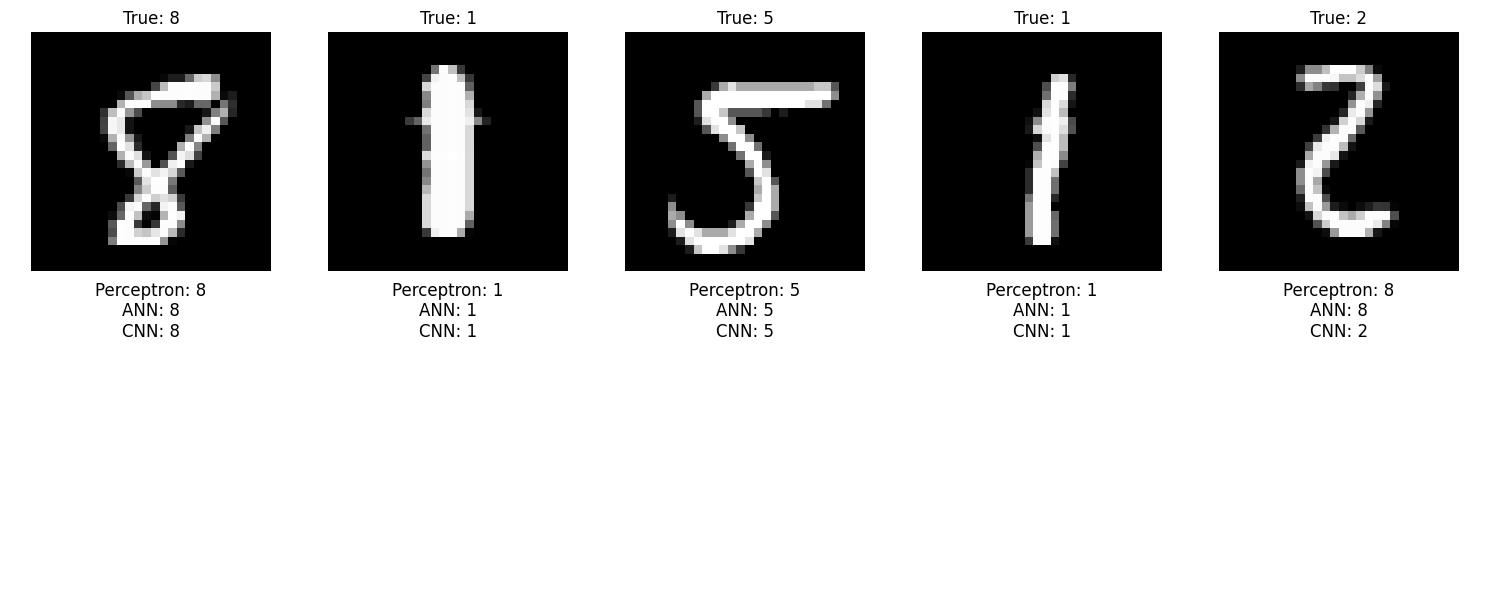

In [18]:
def show_side_by_side(models, model_names, x, x_cnn, y_true, n=5):
    idxs = np.random.choice(len(x), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(x[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(x_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else x[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()


show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], x_test_img, x_test_cnn, y_test, 5)